# Исследовательский анализ данных Retailrocket

Первичный анализ данных итогового проекта: поведение посетителей интернет-магазина,
популярность товаров, структура каталога и качество исходных данных. По результатам
выбираются схема разбиения по времени, веса событий и набор признаков для моделей
рекомендаций.

Источники данных:
- события — таблица `retailrocket_events` в учебной Postgres (залита скриптом
  `scripts/load_events_to_pg.py` из `events.csv`);
- каталог товаров — `recsys_final/data/items.parquet` в S3 (собран скриптом
  `scripts/build_items_catalog.py` из `item_properties_part1/2.csv` и `category_tree.csv`);
- сырые свойства товаров и дерево категорий — `../data/item_properties_part1.csv` и
  `../data/category_tree.csv` (распакованный архив датасета, в репозиторий не коммитится).

## Инициализация

Импорты, доступы из `.env` через пакет `recsys` и параметры ноутбука.

In [1]:
import os
import sys
import time
import gc

sys.path.insert(0, os.path.abspath(".."))

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine

from recsys.config import ITEMS_PATH, SEED, postgres_credentials
from recsys.s3_io import read_parquet

%matplotlib inline
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
np.random.seed(SEED)

# --- Параметры проекта ---
EVENTS_TABLE         = "retailrocket_events"                  # таблица событий в учебной Postgres
CATEGORY_TREE_PATH   = "../data/category_tree.csv"            # дерево категорий из архива датасета
ITEM_PROPERTIES_PATH = "../data/item_properties_part1.csv"    # сырые свойства товаров, часть 1
CATALOG_CUTOFF = pd.Timestamp("2015-08-04")   # отсечка, по которой собран items.parquet
EVENT_TYPES    = ["view", "addtocart", "transaction"]   # порядок событий в воронке
TOP_N          = 15   # длина топов в таблицах и на графиках

## Загрузка данных

События берём из Postgres целиком: 2.7 млн строк — это около 220 МБ в памяти,
чанкование не требуется. Каталог товаров читаем из S3, дерево категорий — из
локальной копии архива датасета.

In [2]:
# строка подключения собирается из .env, пароль в ноутбуке нигде не печатается
pc = postgres_credentials
engine = create_engine(
    f"postgresql+psycopg2://{pc['user']}:{pc['password']}"
    f"@{pc['host']}:{pc['port']}/{pc['dbname']}",
    connect_args={"sslmode": "require"},
)

t0 = time.time()
events = pd.read_sql(
    f"select event_ts, visitorid, event, itemid, transactionid from {EVENTS_TABLE}",
    engine,
)
print(f"событий: {len(events):,} строк, загружено за {time.time() - t0:.1f} сек")
print(f"память: {events.memory_usage(deep=True).sum() / 1024 ** 2:.1f} МБ")

событий: 2,756,101 строк, загружено за 58.1 сек
память: 223.9 МБ


In [3]:
items = read_parquet(ITEMS_PATH)
category_tree = pd.read_csv(CATEGORY_TREE_PATH)

print(f"каталог товаров: {items.shape} | дерево категорий: {category_tree.shape}")

каталог товаров: (235061, 4) | дерево категорий: (1669, 2)


Проверяем типы и первые строки: в Postgres данные лежат уже приведёнными к типам,
`event_ts` получен из миллисекунд epoch при заливке.

In [4]:
display(events.head())
events.info()
display(items.head())

,event_ts,visitorid,event,itemid,transactionid
0,2015-06-02 05:02:12.117,257597,view,355908,NaN
1,2015-06-02 05:50:14.164,992329,view,248676,NaN
2,2015-06-02 05:13:19.827,111016,view,318965,NaN
3,2015-06-02 05:12:35.914,483717,view,253185,NaN
4,2015-06-02 05:02:17.106,951259,view,367447,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype         
---  ------         -----         
 0   event_ts       datetime64[ns]
 1   visitorid      int64         
 2   event          object        
 3   itemid         int64         
 4   transactionid  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 105.1+ MB


,itemid,available,categoryid,parentid
0,3,0,1171,938.0
1,4,0,1038,1174.0
2,6,0,1091,573.0
3,9,<NA>,<NA>,NaN
4,15,0,722,1110.0


## Объём и период

Считаем базовые размерности: сколько событий, визитеров и товаров и за какой
промежуток времени они собраны.

In [5]:
period_start, period_end = events["event_ts"].min(), events["event_ts"].max()

print("=== Объём и период ===")
print(f"событий:      {len(events):,}")
print(f"визитеров:    {events['visitorid'].nunique():,}")
print(f"товаров:      {events['itemid'].nunique():,}")
print(f"период:       {period_start} — {period_end}")
print(f"длительность: {(period_end - period_start).total_seconds() / 86400:.1f} дней, "
      f"{events['event_ts'].dt.date.nunique()} календарных дат")

=== Объём и период ===
событий:      2,756,101


визитеров:    1,407,580


товаров:      235,061
период:       2015-05-03 03:00:04.384000 — 2015-09-18 02:59:47.788000


длительность: 138.0 дней, 139 календарных дат


Данные покрывают 138 дней — с 3 мая по 18 сентября 2015 года. Этого достаточно,
чтобы вырезать из хвоста несколько непересекающихся окон под валидацию и тест и
при этом оставить на обучение больше трёх месяцев истории.

### Воронка событий

Три типа событий образуют естественную воронку: просмотр, добавление в корзину,
покупка. Целевое действие проекта — `addtocart`, `transaction` считается более
сильным позитивом.

,событий,"доля, %"
event,,
view,2664312,96.67
addtocart,69332,2.52
transaction,22457,0.81


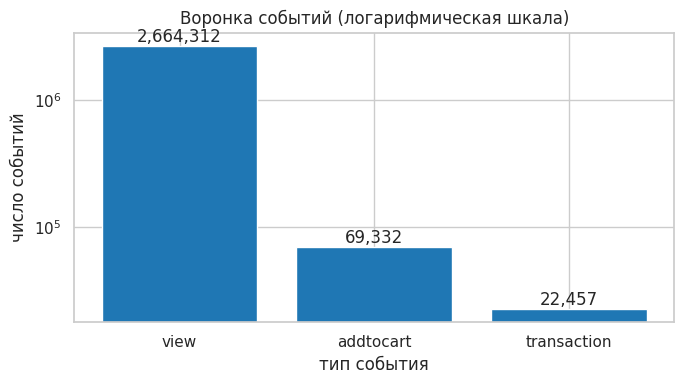

In [6]:
funnel = events["event"].value_counts().reindex(EVENT_TYPES)
display(pd.DataFrame({
    "событий": funnel,
    "доля, %": (funnel / len(events) * 100).round(2),
}))

plt.figure(figsize=(7, 4))
plt.bar(funnel.index, funnel.values, color="tab:blue")
plt.yscale("log")
for i, value in enumerate(funnel.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")
plt.title("Воронка событий (логарифмическая шкала)")
plt.xlabel("тип события")
plt.ylabel("число событий")
plt.tight_layout()
plt.show()

Считаем конверсию `addtocart` → `transaction` на уровне пар (визитер, товар): для
пары берём первое добавление в корзину и последнюю покупку, покупка должна быть не
раньше добавления. Методика намеренно простая, без разбиения на сессии.

In [7]:
addtocart_pairs = (
    events[events["event"] == "addtocart"]
    .groupby(["visitorid", "itemid"])["event_ts"].min().rename("ts_addtocart")
)
transaction_pairs = (
    events[events["event"] == "transaction"]
    .groupby(["visitorid", "itemid"])["event_ts"].max().rename("ts_transaction")
)

pairs = addtocart_pairs.to_frame().join(transaction_pairs, how="left")
converted = pairs["ts_transaction"].notna() & (pairs["ts_transaction"] >= pairs["ts_addtocart"])

print(f"пар (визитер, товар) с addtocart: {len(pairs):,}")
print(f"из них дошли до transaction:      {converted.sum():,} ({converted.mean():.2%})")

пар (визитер, товар) с addtocart: 62,025
из них дошли до transaction:      19,003 (30.64%)


In [8]:
n_visitors = events["visitorid"].nunique()
events_per_visitor = events.groupby("visitorid").size()
visitors_addtocart = events.loc[events["event"] == "addtocart", "visitorid"].nunique()
visitors_transaction = events.loc[events["event"] == "transaction", "visitorid"].nunique()

print("=== Доли визитеров ===")
print(f"больше одного события:    {(events_per_visitor > 1).mean():.2%}")
print(f"хотя бы один addtocart:   {visitors_addtocart:,} ({visitors_addtocart / n_visitors:.2%})")
print(f"хотя бы одна transaction: {visitors_transaction:,} "
      f"({visitors_transaction / n_visitors:.2%})")

=== Доли визитеров ===
больше одного события:    28.85%
хотя бы один addtocart:   37,722 (2.68%)
хотя бы одна transaction: 11,719 (0.83%)


Воронка очень узкая: 96.67 % событий — просмотры, на `addtocart` приходится 2.52 %,
на `transaction` — 0.81 %. При этом сама конверсия из корзины в покупку высокая,
30.64 % пар (визитер, товар) с добавлением в корзину заканчиваются транзакцией, —
то есть проблема не в качестве корзины, а в том, как мало посетителей до неё доходит.
Хотя бы одно добавление в корзину сделали 2.68 % визитеров, хотя бы одну покупку —
0.83 %. Отсюда два следствия для модели: обучать только на `addtocart`/`transaction`
нельзя, позитивов слишком мало, поэтому просмотры войдут в матрицу с меньшим весом;
и качество придётся мерить на небольшой доле визитеров, у которых в тестовом окне
вообще есть целевой сигнал.

## Поведение визитеров

Смотрим, как распределено число событий на визитера — от этого зависит, сколько
пользователей вообще пригодны для персонализации.

In [9]:
print(events_per_visitor.describe(percentiles=[0.5, 0.9, 0.99]).round(2).to_string())

count    1407580.00
mean           1.96
std           12.58
min            1.00
50%            1.00
90%            3.00
99%           13.00
max         7757.00


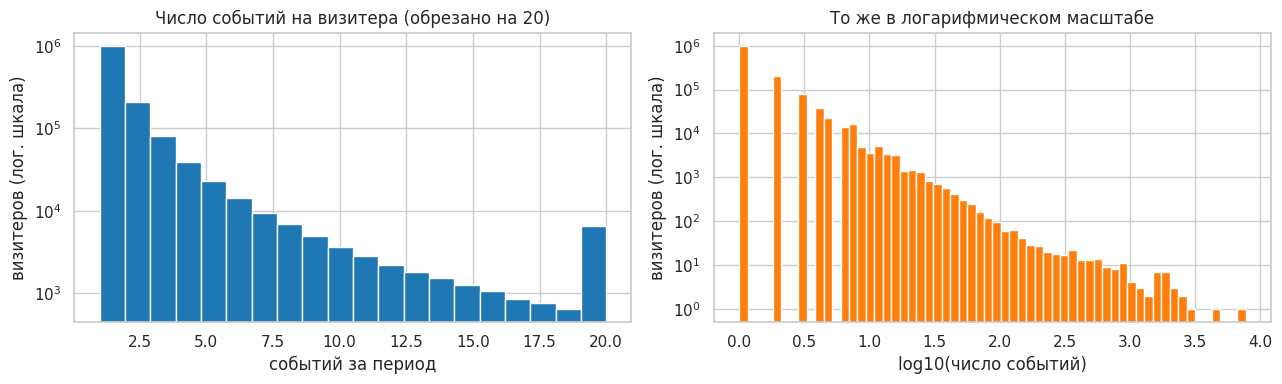

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(events_per_visitor.clip(upper=20), bins=20, color="tab:blue")
ax[0].set_yscale("log")
ax[0].set_title("Число событий на визитера (обрезано на 20)")
ax[0].set_xlabel("событий за период")
ax[0].set_ylabel("визитеров (лог. шкала)")

ax[1].hist(np.log10(events_per_visitor), bins=60, color="tab:orange")
ax[1].set_yscale("log")
ax[1].set_title("То же в логарифмическом масштабе")
ax[1].set_xlabel("log10(число событий)")
ax[1].set_ylabel("визитеров (лог. шкала)")

plt.tight_layout()
plt.show()

Медиана — одно событие на визитера, 71.15 % посетителей за все 138 дней сделали
ровно одно действие и больше не возвращались. Это обычный анонимный трафик
интернет-магазина, персонализировать его нечем: ни истории, ни профиля. Правый
хвост при этом очень длинный — p99 равен 13 событиям, максимум 7 757 у одного
visitorid. Такой разброс означает, что сырые счётчики взаимодействий в матрицу
класть нельзя: несколько сверхактивных визитеров перетянут на себя факторы ALS.
Логарифмирование веса пары гасит этот эффект, сохраняя порядок предпочтений.

### Активность по дням

График нужен, чтобы понять, стабилен ли поток событий, и выбрать точки разбиения
по времени.

In [11]:
per_day = events.groupby(events["event_ts"].dt.date).size()
per_day_type = (
    events.groupby([events["event_ts"].dt.date, "event"]).size()
    .unstack(fill_value=0)
    .reindex(columns=EVENT_TYPES)
)

print(f"событий в день: min {per_day.min():,}, медиана {per_day.median():,.0f}, "
      f"max {per_day.max():,}, среднее {per_day.mean():,.0f}")
print(f"коэффициент вариации: {per_day.std() / per_day.mean():.3f}")
display(per_day.tail(5).to_frame("событий"))

событий в день: min 1,528, медиана 20,621, max 32,703, среднее 19,828
коэффициент вариации: 0.210


,событий
event_ts,
2015-09-14,20913
2015-09-15,20427
2015-09-16,11495
2015-09-17,10128
2015-09-18,1528


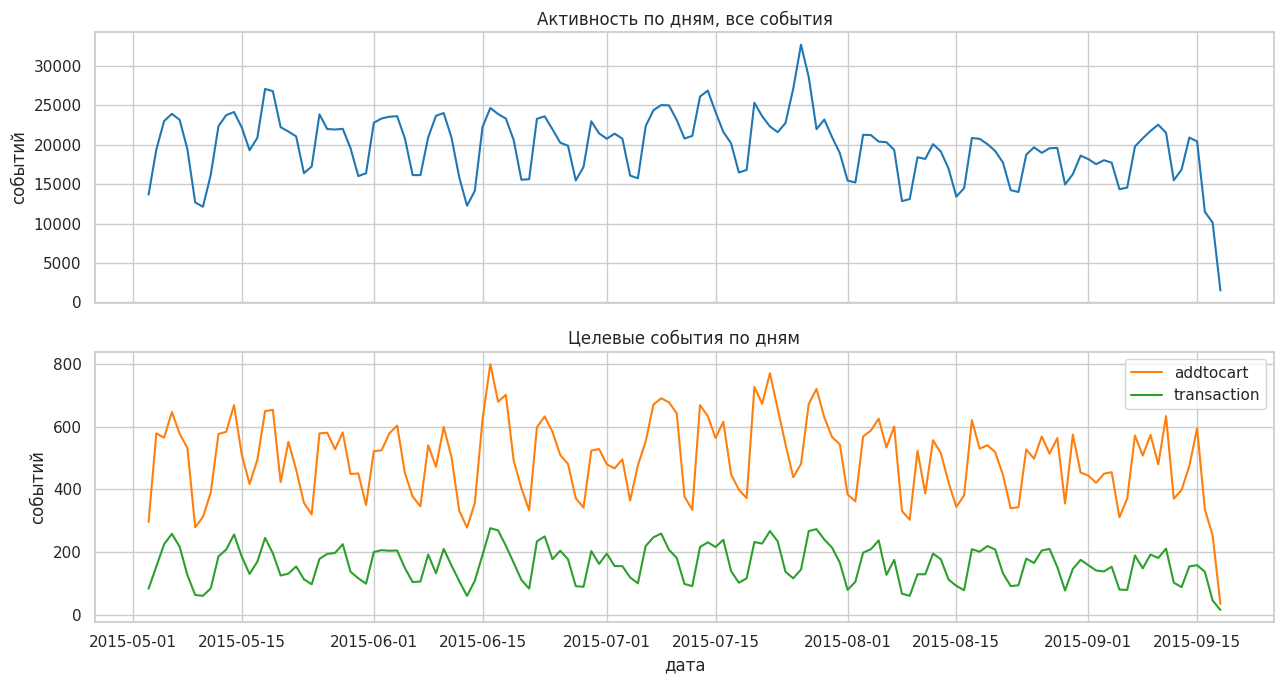

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax[0].plot(per_day.index, per_day.values, color="tab:blue")
ax[0].set_title("Активность по дням, все события")
ax[0].set_ylabel("событий")

ax[1].plot(per_day_type.index, per_day_type["addtocart"],
           color="tab:orange", label="addtocart")
ax[1].plot(per_day_type.index, per_day_type["transaction"],
           color="tab:green", label="transaction")
ax[1].set_title("Целевые события по дням")
ax[1].set_xlabel("дата")
ax[1].set_ylabel("событий")
ax[1].legend()

plt.tight_layout()
plt.show()

Поток событий ровный: медиана 20 621 событие в день при коэффициенте вариации 0.21,
без провалов и всплесков на порядок. Заметен недельный цикл и общий рост уровня к
концу периода. Два последних дня выбиваются вниз (10 128 и 1 528 событий) — выгрузка
обрывается 18 сентября в 02:59, то есть последняя календарная дата неполная и
отдельным окном быть не может. Ровная нагрузка означает, что разбиение по времени
можно делать простыми равными окнами: последние 45 дней (с 4 августа) естественно
режутся на три непересекающихся отрезка по 15 дней — валидация, окно для таргета
ранжировщика и тест, каждый примерно по 300 тыс. событий. Это предложение из плана
проекта; окончательные даты фиксируются на этапе обучения моделей, здесь важно
лишь то, что данные такому разбиению не мешают.

## Товары

Проверяем длинный хвост популярности: сколько товаров реально набирают
взаимодействия и у скольких из них есть целевой сигнал.

In [13]:
item_popularity = events.groupby("itemid").size().sort_values(ascending=False)
viewed_once = (item_popularity == 1).sum()
items_addtocart = events.loc[events["event"] == "addtocart", "itemid"].nunique()
items_transaction = events.loc[events["event"] == "transaction", "itemid"].nunique()
top_one_percent = int(len(item_popularity) * 0.01)

print(f"товаров в событиях:            {len(item_popularity):,}")
print(f"ровно одно событие за период:  {viewed_once:,} "
      f"({viewed_once / len(item_popularity):.2%})")
print(f"есть хотя бы один addtocart:   {items_addtocart:,} "
      f"({items_addtocart / len(item_popularity):.2%})")
print(f"есть хотя бы одна transaction: {items_transaction:,} "
      f"({items_transaction / len(item_popularity):.2%})")
print(f"доля событий у верхнего 1% товаров: "
      f"{item_popularity.head(top_one_percent).sum() / item_popularity.sum():.2%}")

товаров в событиях:            235,061
ровно одно событие за период:  73,609 (31.31%)
есть хотя бы один addtocart:   23,903 (10.17%)
есть хотя бы одна transaction: 12,025 (5.12%)
доля событий у верхнего 1% товаров: 22.95%


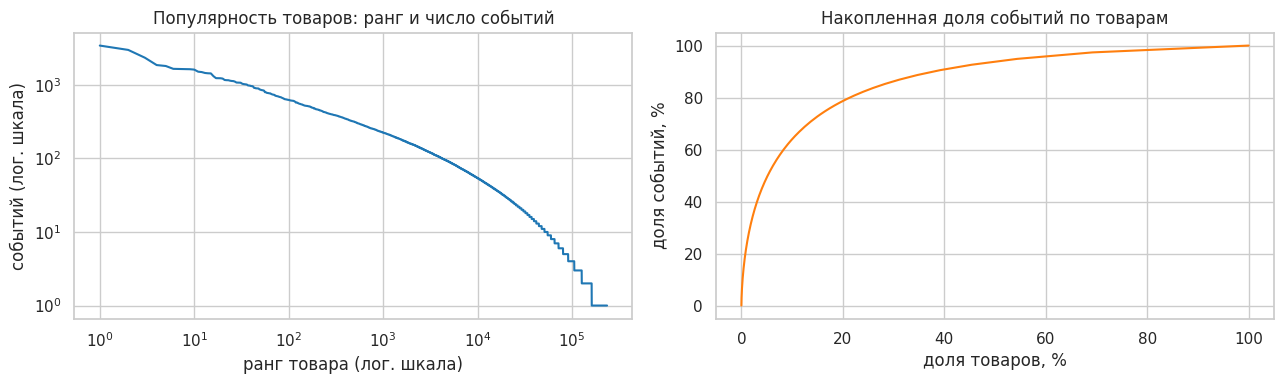

In [14]:
cumulative_share = item_popularity.cumsum() / item_popularity.sum()
item_ranks = np.arange(1, len(item_popularity) + 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(item_ranks, item_popularity.values, color="tab:blue")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_title("Популярность товаров: ранг и число событий")
ax[0].set_xlabel("ранг товара (лог. шкала)")
ax[0].set_ylabel("событий (лог. шкала)")

ax[1].plot(item_ranks / len(item_popularity) * 100, cumulative_share.values * 100,
           color="tab:orange")
ax[1].set_title("Накопленная доля событий по товарам")
ax[1].set_xlabel("доля товаров, %")
ax[1].set_ylabel("доля событий, %")

plt.tight_layout()
plt.show()

Распределение популярности — классический длинный хвост, на лог-логарифмическом
графике он почти прямая. Верхний 1 % товаров (2 350 позиций) собирает 22.95 % всех
событий, а 31.31 % товаров за весь период получили ровно одно событие. Целевой
сигнал ещё более редкий: добавления в корзину есть у 23 903 товаров (10.17 %
каталога), покупки — у 12 025 (5.12 %). Практический вывод: рекомендовать «всё, что
есть в каталоге» бессмысленно, кандидатов нужно ограничивать популярным ядром, а
coverage@k у топ-популярного бейзлайна заведомо будет околонулевым и должен
улучшаться у персональных моделей.

### Категории

Единственный пригодный контентный признак — категория товара. Смотрим, как устроено
дерево категорий и какие категории дают больше всего добавлений в корзину.

In [15]:
# глубина = число уровней от корня, у корневых категорий parentid пустой
parent_of = dict(zip(category_tree["categoryid"], category_tree["parentid"]))


def category_depth(category_id):
    depth, current = 1, category_id
    while pd.notna(parent_of.get(current)):
        current = int(parent_of[current])
        depth += 1
    return depth


category_tree["depth"] = category_tree["categoryid"].map(category_depth)

print(f"категорий в дереве:           {len(category_tree):,}")
print(f"корневых (без родителя):      {category_tree['parentid'].isna().sum()}")
print(f"максимальная глубина:         {category_tree['depth'].max()}")
print(f"категорий в каталоге товаров: {items['categoryid'].nunique():,}")
display(category_tree["depth"].value_counts().sort_index().to_frame("категорий"))

категорий в дереве:           1,669
корневых (без родителя):      25
максимальная глубина:         6
категорий в каталоге товаров: 1,074


,категорий
depth,
1,25
2,174
3,702
4,665
5,90
6,13


addtocart без известной категории:   2,723 (3.93%)
категорий, в которых есть addtocart: 750


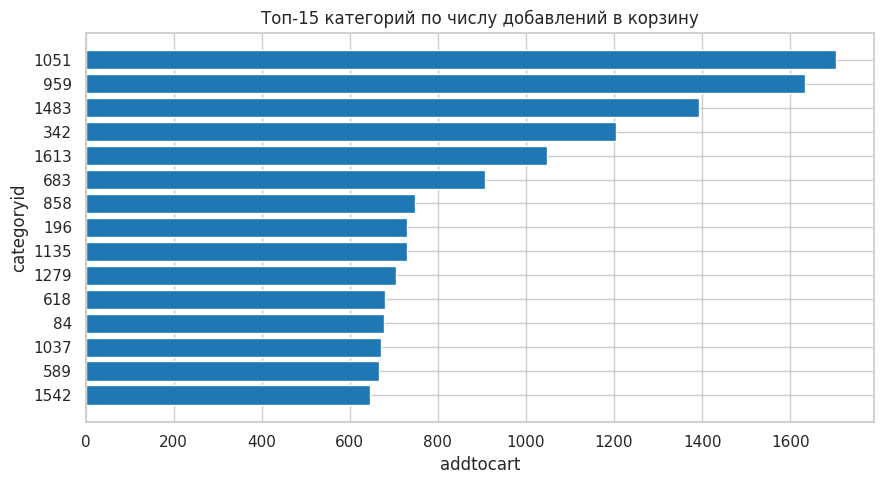

In [16]:
addtocart_items = events[events["event"] == "addtocart"].merge(
    items[["itemid", "categoryid"]], how="left", on="itemid"
)
top_categories = (
    addtocart_items.dropna(subset=["categoryid"])
    .groupby("categoryid").size().sort_values(ascending=False).head(TOP_N)
)

print(f"addtocart без известной категории:   {addtocart_items['categoryid'].isna().sum():,} "
      f"({addtocart_items['categoryid'].isna().mean():.2%})")
print(f"категорий, в которых есть addtocart: {addtocart_items['categoryid'].nunique():,}")

plt.figure(figsize=(9, 5))
plt.barh(top_categories.index.astype(str), top_categories.values, color="tab:blue")
plt.gca().invert_yaxis()
plt.title(f"Топ-{TOP_N} категорий по числу добавлений в корзину")
plt.xlabel("addtocart")
plt.ylabel("categoryid")
plt.tight_layout()
plt.show()

In [17]:
# available: 1 — товар в наличии на дату отсечки, 0 — нет, пусто — свойство неизвестно
display(items["available"].value_counts(dropna=False).to_frame("товаров"))

,товаров
available,
0,135738
<NA>,53640
1,45683


Дерево категорий небольшое и неглубокое: 1 669 категорий, 25 корней, максимум
6 уровней, основная масса сосредоточена на третьем и четвёртом уровне. В каталоге
товаров встречается 1 074 категории, добавления в корзину есть в 750 из них.
Топ категорий по `addtocart` пологий — у лидера 1 705 добавлений против 1 204
у четвёртой позиции, то есть спрос не сконцентрирован в одной-двух категориях.
Поле `available` заполнено далеко не у всех: у 53 640 товаров оно неизвестно, а из
известных в наличии на дату отсечки числятся только 45 683 против 135 738
отсутствующих. Как фильтр выдачи `available` использовать рискованно — данные
разреженные и быстро устаревают; как признак ранжировщика оно вполне пригодно.

## Сырые свойства товаров

Каталог `items.parquet` собран всего из двух свойств — `categoryid` и `available`.
Проверим на сырых данных, почему остальные не используются. Для этого хватит первой
части файла свойств (`item_properties_part1.csv`), вторая устроена так же.

In [18]:
t0 = time.time()
item_properties = pd.read_csv(
    ITEM_PROPERTIES_PATH, usecols=["timestamp", "itemid", "property", "value"]
)
item_properties["ts"] = pd.to_datetime(item_properties["timestamp"], unit="ms")

property_counts = item_properties["property"].value_counts()

print(f"строк:             {len(item_properties):,}")
print(f"товаров:           {item_properties['itemid'].nunique():,}")
print(f"свойств:           {property_counts.size:,}")
print(f"срезов по времени: {item_properties['ts'].nunique()} "
      f"({item_properties['ts'].min().date()} — {item_properties['ts'].max().date()})")
print(f"прочитано за {time.time() - t0:.1f} сек")
display(property_counts.head(TOP_N).to_frame("строк"))

строк:             10,999,999


товаров:           417,053
свойств:           1,097


срезов по времени: 18 (2015-05-10 — 2015-09-13)
прочитано за 31.0 сек


,строк
property,
888,1629817
790,970800
available,817387
categoryid,426305
6,343207
283,323681
776,311654
678,261829
364,256340


Смотрим сами значения у самых частых свойств: двух топовых (`888`, `790`), одного
из середины (`6`) и двух читаемых (`categoryid`, `available`).

In [19]:
for prop in ["888", "790", "6", "categoryid", "available"]:
    values = item_properties.loc[item_properties["property"] == prop, "value"]
    print(f"--- property {prop}: строк {len(values):,}, "
          f"уникальных значений {values.nunique():,}")
    for value in values.head(3).tolist():
        print(f"    {value}")

--- property 888: строк 1,629,817, уникальных значений 281,842
    1116713 960601 n277.200
    1038400 45956 n504.000
    1292080


--- property 790: строк 970,800, уникальных значений 25,995
    n15360.000
    n21000.000
    n5400.000


--- property 6: строк 343,207, уникальных значений 4,134
    319724
    1214748 1186610
    377560


--- property categoryid: строк 426,305, уникальных значений 1,196
    1338
    1277
    1059


--- property available: строк 817,387, уникальных значений 2
    0
    0
    0


Из 1 097 свойств осмысленные имена только у двух — `categoryid` и `available`.
Остальные обозначены числовыми идентификаторами, а их значения захэшированы:
свойство `888` (1 629 817 строк, самое частое) хранит наборы токенов вида
`1116713 960601 n277.200`, свойство `790` — только числа с префиксом `n`
(`n15360.000`), свойство `6` — снова списки непрозрачных идентификаторов.
Восстановить, что означает конкретный токен, нечем: словаря значений в датасете нет,
а внутри одного свойства их десятки и сотни тысяч (у `888` — 281 842 уникальных
значения). Использовать такие признаки можно было бы только как обезличенные
категориальные хэши, что при 235 тыс. товаров даёт огромную разреженную матрицу без
всякой интерпретации. Поэтому в каталог берутся только `categoryid` и `available`,
а контентная часть проекта ограничивается категорией.

Отдельно проверим, меняются ли значения свойств во времени: файл содержит
еженедельные срезы, и если свойство обновляется, то «последнее известное значение»
зависит от того, на какую дату мы смотрим.

In [20]:
value_changes = item_properties.groupby(["itemid", "property"])["value"].nunique()
drifted = value_changes > 1

print(f"пар (товар, свойство): {len(value_changes):,}")
print(f"значение менялось:     {drifted.sum():,} ({drifted.mean():.2%})")
print(f"срезов до отсечки {CATALOG_CUTOFF.date()}: "
      f"{item_properties.loc[item_properties['ts'] < CATALOG_CUTOFF, 'ts'].nunique()} "
      f"из {item_properties['ts'].nunique()}")

for prop in ["categoryid", "available"]:
    mask = value_changes.index.get_level_values("property") == prop
    changed = value_changes[mask] > 1
    print(f"{prop}: менялось у {changed.sum():,} товаров из {mask.sum():,} "
          f"({changed.mean():.2%})")

пар (товар, свойство): 6,592,335
значение менялось:     307,624 (4.67%)


срезов до отсечки 2015-08-04: 12 из 18


categoryid: менялось у 14,267 товаров из 229,341 (6.22%)


available: менялось у 40,877 товаров из 236,884 (17.26%)


In [21]:
# свойства больше не нужны, освобождаем память перед разделом о качестве данных
del item_properties, value_changes
gc.collect()

43003

Свойства действительно дрейфуют: у 4.67 % пар (товар, свойство) значение менялось
хотя бы раз за 18 недельных срезов. По двум нужным нам свойствам картина разная —
`categoryid` переезжает редко (6.22 % товаров), а `available` меняется у 17.26 %,
что естественно для признака наличия. Значит, брать «последнее известное значение»
по всему файлу нельзя: для товара, который к сентябрю пропал из продажи, это была бы
информация из будущего относительно обучающего окна. В каталоге `items.parquet`
значение берётся на дату отсечки 2015-08-04 — границу обучающей выборки; в первой
части файла до этой даты попадают 12 срезов из 18.

## Пропуски и качество данных

Проверяем покрытие каталога, дубли и аномалии во временных метках.

In [22]:
events_with_category = events.merge(items[["itemid", "categoryid"]], how="left", on="itemid")
no_category = events_with_category["categoryid"].isna()

print(f"событий без известной категории товара: {no_category.sum():,} "
      f"({no_category.mean():.2%})")
print(f"товаров каталога без categoryid:        {items['categoryid'].isna().sum():,} "
      f"({items['categoryid'].isna().mean():.2%})")
print(f"товаров каталога без available:         {items['available'].isna().sum():,}")
print(f"товаров каталога без parentid:          {items['parentid'].isna().sum():,}")

событий без известной категории товара: 305,342 (11.08%)
товаров каталога без categoryid:        54,705 (23.27%)
товаров каталога без available:         53,640
товаров каталога без parentid:          54,707


In [23]:
duplicated = events.duplicated(
    subset=["event_ts", "visitorid", "event", "itemid", "transactionid"]
)
print(f"полных дублей строк: {duplicated.sum():,}")
display(events[duplicated].head())

полных дублей строк: 460


,event_ts,visitorid,event,itemid,transactionid
22404,2015-06-01 17:46:21.440,1045411,addtocart,379647,NaN
34465,2015-06-02 19:43:43.925,366538,addtocart,252068,NaN
39738,2015-06-02 17:11:40.661,198153,addtocart,48715,NaN
41774,2015-06-02 18:47:48.154,1268755,view,60980,NaN
42469,2015-06-02 20:32:14.682,555487,addtocart,397642,NaN


In [24]:
print(f"первое событие:    {events['event_ts'].min()}")
print(f"последнее событие: {events['event_ts'].max()}")
print(f"событий в последний календарный день: {per_day.iloc[-1]:,}")
print(f"пропусков в event_ts: {events['event_ts'].isna().sum()}")
print("типы событий с заполненным transactionid: "
      f"{events.loc[events['transactionid'].notna(), 'event'].unique().tolist()}")
print("transaction без transactionid: "
      f"{((events['event'] == 'transaction') & events['transactionid'].isna()).sum()}")

первое событие:    2015-05-03 03:00:04.384000
последнее событие: 2015-09-18 02:59:47.788000
событий в последний календарный день: 1,528
пропусков в event_ts: 0
типы событий с заполненным transactionid: ['transaction']


transaction без transactionid: 0


Данные чистые, но неполные. Пропусков во времени и идентификаторах нет,
`transactionid` заполнен ровно у событий покупки и только у них. Полных дублей строк
460 из 2.76 млн — доли процента; на статистику они не влияют, а при сборке матрицы
взаимодействий пары всё равно агрегируются, так что дубли схлопнутся сами. Главный
пробел — каталог: у 23.27 % товаров, встречающихся в событиях, на дату отсечки нет
ни одного свойства, и это 11.08 % всех событий. Для таких товаров контентных
признаков не будет вовсе, и ранжировщик должен уметь работать с пустой категорией.
Границы периода приходятся на 03:00 — выгрузка нарезана по локальному времени
магазина, поэтому первая и последняя календарные даты неполные.

## Разреженность матрицы визитер-товар

Оцениваем, с какой плотностью придётся работать ALS.

In [25]:
pair_counts = events.groupby(["visitorid", "itemid"]).size()
n_items = events["itemid"].nunique()
density = len(pair_counts) / (n_visitors * n_items)

target_pairs = (
    events[events["event"].isin(["addtocart", "transaction"])]
    .groupby(["visitorid", "itemid"]).size()
)

print(f"размер матрицы:                  {n_visitors:,} x {n_items:,}")
print(f"уникальных пар (визитер, товар): {len(pair_counts):,}")
print(f"из них с повторами:              {(pair_counts > 1).sum():,} "
      f"({(pair_counts > 1).mean():.2%})")
print(f"плотность:                       {density:.2e}")
print(f"пар с целевым сигналом:          {len(target_pairs):,} "
      f"({len(target_pairs) / len(pair_counts):.2%})")

размер матрицы:                  1,407,580 x 235,061
уникальных пар (визитер, товар): 2,145,179
из них с повторами:              333,038 (15.52%)
плотность:                       6.48e-06
пар с целевым сигналом:          64,250 (3.00%)


Матрица визитер-товар имеет размер 1 407 580 на 235 061 и заполнена на 6.48e-06 —
примерно шесть ячеек на миллион. Для implicit ALS это штатный режим работы, но он же
объясняет, почему абсолютные значения precision и recall в таких задачах низкие:
у большинства строк матрицы всего одно ненулевое значение. Повторные обращения к
одному и тому же товару есть у 15.52 % пар — этого достаточно, чтобы взвешивание по
числу событий имело смысл. Пар с целевым сигналом (`addtocart` или `transaction`)
всего 64 250, то есть 3 % от всех пар: если обучать ALS только на них, матрица станет
вырожденной, поэтому просмотры остаются в обучении как слабый позитив.

## Итоговые выводы

1. **Объём и период.** 2 756 101 событие за 138 дней (3 мая — 18 сентября 2015),
   1 407 580 визитеров, 235 061 товар. Поток ровный (медиана 20 621 событие в день,
   коэффициент вариации 0.21), поэтому разбиение по времени можно делать равными
   окнами: последние 45 дней режутся на три отрезка по 15 дней под валидацию, таргет
   ранжировщика и тест. Последняя календарная дата неполная, её нужно учитывать при
   выборе границ.
2. **Воронка и конверсия.** view 2 664 312 (96.67 %), addtocart 69 332 (2.52 %),
   transaction 22 457 (0.81 %). Конверсия из корзины в покупку на уровне пар
   (визитер, товар) — 30.64 %. Целевой сигнал редкий: хотя бы одно добавление в
   корзину сделали 2.68 % визитеров, покупку — 0.83 %.
3. **Веса событий.** 71.15 % визитеров сделали ровно одно событие, при этом максимум
   у одного visitorid — 7 757 событий. Обучать только на целевых событиях нельзя
   (64 250 пар против 2 145 179), поэтому просмотры входят в матрицу с меньшим весом,
   а сам вес пары логарифмируется, чтобы сверхактивные визитеры не перетянули на себя
   факторы ALS.
4. **Разреженность.** 2 145 179 уникальных пар на матрицу 1 407 580 x 235 061 —
   плотность 6.48e-06. Это нормально для implicit ALS, но задаёт низкий потолок
   абсолютных значений precision@k и recall@k: модели имеет смысл сравнивать между
   собой, а не с абстрактной «хорошей» цифрой.
5. **Холодный старт.** Подавляющее большинство визитеров приходят один раз и не имеют
   истории, а 31.31 % товаров за весь период получили ровно одно событие. Сервис
   обязан отдавать осмысленный ответ при пустой истории, поэтому топ популярных
   товаров нужен не только как бейзлайн, но и как рабочая ветка выдачи.
6. **Кандидаты и метрики.** Верхний 1 % товаров собирает 22.95 % событий, добавления
   в корзину есть только у 23 903 товаров (10.17 % каталога). Отбор кандидатов имеет
   смысл ограничивать популярным ядром, а coverage@k и novelty@k включать в набор
   метрик — иначе выбор модели сведётся к переоценке популярного.
7. **Контентные признаки.** Из 1 097 свойств в `item_properties` читаемы только
   `categoryid` и `available`, остальные захэшированы и не расшифровываются
   (у самого частого свойства `888` — 281 842 уникальных значения без словаря).
   Единственный пригодный контентный признак — категория товара и её родитель из
   дерева на 1 669 категорий (25 корней, 6 уровней).
8. **Качество данных.** Пропусков во времени и идентификаторах нет, полных дублей
   460 строк, `transactionid` заполнен ровно у покупок. Основной пробел — каталог:
   у 23.27 % товаров нет свойств на дату отсечки, что покрывает 11.08 % событий;
   ранжировщик должен работать с пустой категорией.
9. **Дрейф свойств.** Значения меняются у 4.67 % пар (товар, свойство), в том числе
   у 6.22 % товаров по `categoryid` и 17.26 % по `available`. Поэтому каталог
   собирается на дату отсечки 2015-08-04, а не по последнему известному значению —
   иначе в признаки попадает информация из будущего относительно обучающего окна.